# 💼 Job Description Skill Extractor + Resume Matcher
## NLP Capstone Project 2 — PGA 45
**Author:** Amit Kumar | Data Scientist | Bangalore

---
### 🎯 What This System Does:
1. **Skill Extraction** — Extracts technical & soft skills from any Job Description using NLP
2. **Resume Parser** — Parses resume text and extracts candidate skills
3. **Match Scoring** — Computes similarity score between JD and Resume using TF-IDF + Cosine Similarity
4. **Gap Analysis** — Identifies missing skills and matching skills
5. **Visualization Dashboard** — Charts showing match %, skill overlap, top demanded skills

### ✅ Runtime: CPU is fine for this project. GPU not required.

In [4]:
!pip install -q transformers
!pip install -q sentence-transformers
!pip install -q spacy
!pip install -q datasets
!pip install -q plotly
!pip install -q wordcloud
!pip install -q scikit-learn

## 📚 Step 2 — Imports & Setup

In [6]:
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import pipeline

# Add the download commands directly here to ensure models are available
# even if the preceding cell was not run or failed.
!python -m spacy download en_core_web_sm
!python -m spacy download en_core_web_md

# Load spaCy models
nlp_sm = spacy.load('en_core_web_sm')
nlp_md = spacy.load('en_core_web_md')

# Load sentence transformer for semantic similarity
print("Loading semantic model...")
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

print("✅ All imports done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 22.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Loading semantic model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ All imports done!


## 🗂️ Step 3 — Skill Taxonomy (Knowledge Base)
> This is our reference dictionary of skills — technical, tools, soft skills, domains.
> In production, companies like LinkedIn maintain taxonomies of 40,000+ skills.

In [7]:
# Comprehensive skill taxonomy
SKILL_TAXONOMY = {
    "Programming Languages": [
        "python", "java", "javascript", "typescript", "c++", "c#", "r", "scala",
        "go", "rust", "kotlin", "swift", "php", "ruby", "matlab", "bash", "shell"
    ],
    "Data Science & ML": [
        "machine learning", "deep learning", "neural networks", "nlp",
        "natural language processing", "computer vision", "reinforcement learning",
        "feature engineering", "model evaluation", "statistics", "data analysis",
        "predictive modeling", "time series", "regression", "classification",
        "clustering", "dimensionality reduction", "transfer learning"
    ],
    "ML Frameworks & Libraries": [
        "tensorflow", "pytorch", "keras", "scikit-learn", "sklearn", "xgboost",
        "lightgbm", "catboost", "hugging face", "transformers", "spacy", "nltk",
        "opencv", "pandas", "numpy", "scipy", "matplotlib", "seaborn", "plotly"
    ],
    "Generative AI & LLMs": [
        "llm", "large language models", "gpt", "bert", "rag",
        "retrieval augmented generation", "prompt engineering", "langchain",
        "llamaindex", "vector database", "faiss", "chromadb", "fine-tuning",
        "embeddings", "openai api", "hugging face", "llama", "mistral"
    ],
    "Cloud & DevOps": [
        "aws", "azure", "gcp", "google cloud", "docker", "kubernetes",
        "mlflow", "airflow", "ci/cd", "git", "github", "terraform",
        "lambda", "ec2", "s3", "bigquery", "databricks", "spark"
    ],
    "Databases & Storage": [
        "sql", "mysql", "postgresql", "mongodb", "redis", "elasticsearch",
        "cassandra", "snowflake", "redshift", "hive", "hadoop", "nosql"
    ],
    "Data Visualization & BI": [
        "power bi", "tableau", "excel", "looker", "superset", "grafana",
        "matplotlib", "seaborn", "plotly", "dashboard", "data visualization"
    ],
    "Soft Skills": [
        "communication", "teamwork", "leadership", "problem solving",
        "critical thinking", "project management", "agile", "scrum",
        "collaboration", "presentation", "analytical thinking", "stakeholder management"
    ],
    "Domain Knowledge": [
        "finance", "healthcare", "e-commerce", "retail", "banking",
        "insurance", "supply chain", "marketing analytics", "product analytics",
        "risk management", "fraud detection", "recommendation systems"
    ]
}

# Flatten for quick lookup
ALL_SKILLS = {}
for category, skills in SKILL_TAXONOMY.items():
    for skill in skills:
        ALL_SKILLS[skill.lower()] = category

print(f"✅ Skill taxonomy loaded!")
print(f"   Total categories : {len(SKILL_TAXONOMY)}")
print(f"   Total skills     : {len(ALL_SKILLS)}")
for cat, skills in SKILL_TAXONOMY.items():
    print(f"   [{cat}] → {len(skills)} skills")

✅ Skill taxonomy loaded!
   Total categories : 9
   Total skills     : 133
   [Programming Languages] → 17 skills
   [Data Science & ML] → 18 skills
   [ML Frameworks & Libraries] → 19 skills
   [Generative AI & LLMs] → 18 skills
   [Cloud & DevOps] → 18 skills
   [Databases & Storage] → 12 skills
   [Data Visualization & BI] → 11 skills
   [Soft Skills] → 12 skills
   [Domain Knowledge] → 12 skills


## 📄 Step 4 — Sample Job Descriptions & Resumes

In [8]:
# ── 5 Real-world Job Descriptions ──
job_descriptions = {
    "JD_1": {
        "title": "Data Scientist — Flipkart",
        "company": "Flipkart",
        "text": """
        We are looking for a Data Scientist to join Flipkart's personalization team.
        Requirements:
        - Strong proficiency in Python and R for data analysis and modeling
        - Experience with machine learning frameworks: scikit-learn, XGBoost, LightGBM
        - Solid understanding of NLP techniques including text classification and sentiment analysis
        - Hands-on experience with deep learning using TensorFlow or PyTorch
        - Proficiency in SQL for data extraction and transformation
        - Experience with cloud platforms, preferably AWS or GCP
        - Strong knowledge of statistics, regression, classification, and clustering
        - Experience with feature engineering and model evaluation metrics
        - Familiarity with Power BI or Tableau for visualization
        - Good communication skills and ability to present insights to stakeholders
        - Experience with A/B testing and hypothesis testing
        - Knowledge of recommendation systems is a plus
        - Experience with Spark or distributed computing is preferred
        """
    },
    "JD_2": {
        "title": "NLP Engineer — Swiggy",
        "company": "Swiggy",
        "text": """
        Swiggy is hiring an NLP Engineer to build intelligent food ordering experiences.
        Requirements:
        - 2+ years of experience in NLP and text processing
        - Proficiency in Python with strong knowledge of NLP libraries: spaCy, NLTK, Hugging Face
        - Experience fine-tuning BERT, RoBERTa or similar transformer models
        - Hands-on with RAG pipelines, vector databases like FAISS or ChromaDB
        - Experience with LangChain or LlamaIndex for LLM application development
        - Strong SQL skills for data pipeline work
        - Experience deploying ML models using FastAPI and Docker
        - Knowledge of prompt engineering and LLM evaluation
        - Familiarity with MLflow for experiment tracking
        - Strong problem solving and communication skills
        - Experience with Git and CI/CD pipelines
        - Understanding of information retrieval and semantic search
        """
    },
    "JD_3": {
        "title": "ML Engineer — Razorpay",
        "company": "Razorpay",
        "text": """
        Razorpay is looking for an ML Engineer to build fraud detection systems.
        Requirements:
        - Strong Python programming skills
        - Experience building ML pipelines end-to-end: data prep, training, evaluation, deployment
        - Hands-on experience with XGBoost, LightGBM, and ensemble methods
        - Knowledge of anomaly detection and fraud detection techniques
        - Experience with AWS services: S3, EC2, Lambda, SageMaker
        - Strong SQL and database skills (PostgreSQL, Redshift)
        - Experience with Docker and Kubernetes for model deployment
        - Familiarity with Airflow for pipeline orchestration
        - Knowledge of MLflow or similar experiment tracking tools
        - Experience with real-time data processing using Kafka or Spark
        - Strong analytical thinking and risk management domain knowledge
        - Agile development experience
        """
    },
    "JD_4": {
        "title": "Data Analyst — Zepto",
        "company": "Zepto",
        "text": """
        Zepto is hiring a Data Analyst for their Private Label business team.
        Requirements:
        - Strong proficiency in SQL for complex data queries
        - Advanced Excel skills including pivot tables, VLOOKUP, macros
        - Experience with Power BI or Tableau for dashboard creation
        - Python knowledge for data manipulation using pandas and numpy
        - Strong analytical thinking and problem solving skills
        - Experience with A/B testing and statistical analysis
        - Good understanding of e-commerce and retail metrics
        - Excellent communication and presentation skills
        - Experience with Google Analytics or similar tools
        - Knowledge of supply chain and inventory analytics is a plus
        - Stakeholder management and cross-functional collaboration
        """
    },
    "JD_5": {
        "title": "GenAI Engineer — Meesho",
        "company": "Meesho",
        "text": """
        Meesho is building next-gen AI features and hiring a Generative AI Engineer.
        Requirements:
        - Strong Python programming skills
        - Hands-on experience with LLMs: GPT, Llama, Mistral
        - Experience building RAG pipelines with FAISS, ChromaDB, or Pinecone
        - Proficiency with LangChain and LlamaIndex frameworks
        - Knowledge of prompt engineering and chain-of-thought prompting
        - Experience with Hugging Face Transformers and fine-tuning LLMs
        - Familiarity with vector embeddings and semantic search
        - Experience deploying AI apps using FastAPI and Docker
        - Knowledge of MLflow for LLM experiment tracking
        - Strong understanding of NLP fundamentals
        - Experience with Git and GitHub for version control
        - Good communication and teamwork skills
        """
    }
}

# ── 3 Sample Resumes ──
resumes = {
    "Resume_Amit": {
        "name": "Amit Kumar",
        "text": """
        ML Engineer and Data Scientist with 2 years of experience.
        Technical Skills:
        Python, SQL, Machine Learning, Deep Learning, NLP, Natural Language Processing
        TensorFlow, Scikit-learn, XGBoost, Pandas, NumPy, Matplotlib, Seaborn
        RAG Pipelines, FAISS, BM25, Hugging Face Transformers, LangChain
        Sentence Transformers, Prompt Engineering, LLM Evaluation
        FastAPI, Docker, Git, GitHub, Hugging Face Spaces
        Power BI, Tableau, Excel, DAX
        BERT, Mistral, FLAN-T5, TinyLlama
        Soft Skills: Communication, Problem Solving, Analytical Thinking, Teamwork
        Domain: E-commerce Analytics, Revenue Analytics, Fraud Detection
        Experience:
        - Revenue Lead at OYO: Excel modeling, KPI dashboards, pricing analytics
        - Data Scientist at Soothsayer Analytics: ML pipelines, NLP, CNN classification
        - Built production RAG system with hybrid FAISS+BM25 retrieval
        - Built Autonomous AI Data Analyst agent using LLM orchestration
        """
    },
    "Resume_B": {
        "name": "Priya Sharma",
        "text": """
        Data Analyst with 3 years of experience in e-commerce analytics.
        Technical Skills:
        SQL, Python, Excel, Power BI, Tableau, Google Analytics
        Pandas, NumPy, Statistics, A/B Testing, Hypothesis Testing
        MySQL, PostgreSQL, Redshift
        Soft Skills: Communication, Presentation, Stakeholder Management,
        Collaboration, Critical Thinking, Agile
        Domain: E-commerce, Retail, Supply Chain, Marketing Analytics
        Experience:
        - Senior Data Analyst at Amazon: SQL dashboards, A/B testing, business insights
        - Data Analyst at Myntra: Power BI dashboards, inventory analytics
        """
    },
    "Resume_C": {
        "name": "Rahul Verma",
        "text": """
        Software Engineer transitioning to ML with 1 year experience.
        Technical Skills:
        Python, Java, JavaScript, Git, GitHub
        Basic machine learning, pandas, numpy
        MySQL, MongoDB
        Docker, AWS basics
        Soft Skills: Problem solving, teamwork, communication, leadership
        Experience:
        - Software Engineer at TCS: Java development, REST APIs
        - Personal projects: Basic classification models, simple NLP tasks
        """
    }
}

print(f"✅ Data loaded!")
print(f"   Job Descriptions : {len(job_descriptions)}")
print(f"   Resumes          : {len(resumes)}")

✅ Data loaded!
   Job Descriptions : 5
   Resumes          : 3


## 🧹 Step 5 — Text Preprocessing & Cleaning

In [9]:
def preprocess_text(text):
    """Clean and normalize text for NLP processing."""
    text = text.lower()
    text = re.sub(r'[\n\r\t]+', ' ', text)
    text = re.sub(r'[^a-z0-9\s+#./]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_skills_from_text(text):
    """
    Extract skills from text using 3 methods:
    1. Direct keyword matching against taxonomy
    2. spaCy noun phrase extraction
    3. Pattern matching for compound skills
    """
    text_lower = preprocess_text(text)
    found_skills = {}

    # Method 1: Direct taxonomy matching
    for skill, category in ALL_SKILLS.items():
        # Use word boundary matching for accuracy
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            found_skills[skill] = category

    # Method 2: spaCy NER for additional entity extraction
    doc = nlp_md(text[:5000])
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'PRODUCT']:
            ent_text = ent.text.lower().strip()
            if ent_text in ALL_SKILLS:
                found_skills[ent_text] = ALL_SKILLS[ent_text]

    return found_skills

# Test on one JD
test_skills = extract_skills_from_text(job_descriptions['JD_1']['text'])
print(f"Skills extracted from Flipkart JD ({len(test_skills)} skills):")
for skill, cat in sorted(test_skills.items(), key=lambda x: x[1]):
    print(f"  [{cat:30s}] → {skill}")

Skills extracted from Flipkart JD (24 skills):
  [Cloud & DevOps                ] → aws
  [Cloud & DevOps                ] → gcp
  [Cloud & DevOps                ] → spark
  [Data Science & ML             ] → machine learning
  [Data Science & ML             ] → deep learning
  [Data Science & ML             ] → nlp
  [Data Science & ML             ] → feature engineering
  [Data Science & ML             ] → model evaluation
  [Data Science & ML             ] → statistics
  [Data Science & ML             ] → data analysis
  [Data Science & ML             ] → regression
  [Data Science & ML             ] → classification
  [Data Science & ML             ] → clustering
  [Data Visualization & BI       ] → power bi
  [Data Visualization & BI       ] → tableau
  [Databases & Storage           ] → sql
  [Domain Knowledge              ] → recommendation systems
  [ML Frameworks & Libraries     ] → tensorflow
  [ML Frameworks & Libraries     ] → pytorch
  [ML Frameworks & Libraries     ] → xg

## 📊 Step 6 — Exploratory Data Analysis (EDA)

In [10]:
# Extract skills from all JDs
print("Extracting skills from all Job Descriptions...\n")
jd_skills = {}
for jd_id, jd in job_descriptions.items():
    skills = extract_skills_from_text(jd['text'])
    jd_skills[jd_id] = skills
    print(f"  {jd['title']}: {len(skills)} skills extracted")

# Extract skills from all resumes
print("\nExtracting skills from all Resumes...\n")
resume_skills = {}
for res_id, res in resumes.items():
    skills = extract_skills_from_text(res['text'])
    resume_skills[res_id] = skills
    print(f"  {res['name']}: {len(skills)} skills extracted")

Extracting skills from all Job Descriptions...

  Data Scientist — Flipkart: 24 skills extracted
  NLP Engineer — Swiggy: 20 skills extracted
  ML Engineer — Razorpay: 19 skills extracted
  Data Analyst — Zepto: 16 skills extracted
  GenAI Engineer — Meesho: 21 skills extracted

Extracting skills from all Resumes...

  Amit Kumar: 33 skills extracted
  Priya Sharma: 20 skills extracted
  Rahul Verma: 18 skills extracted


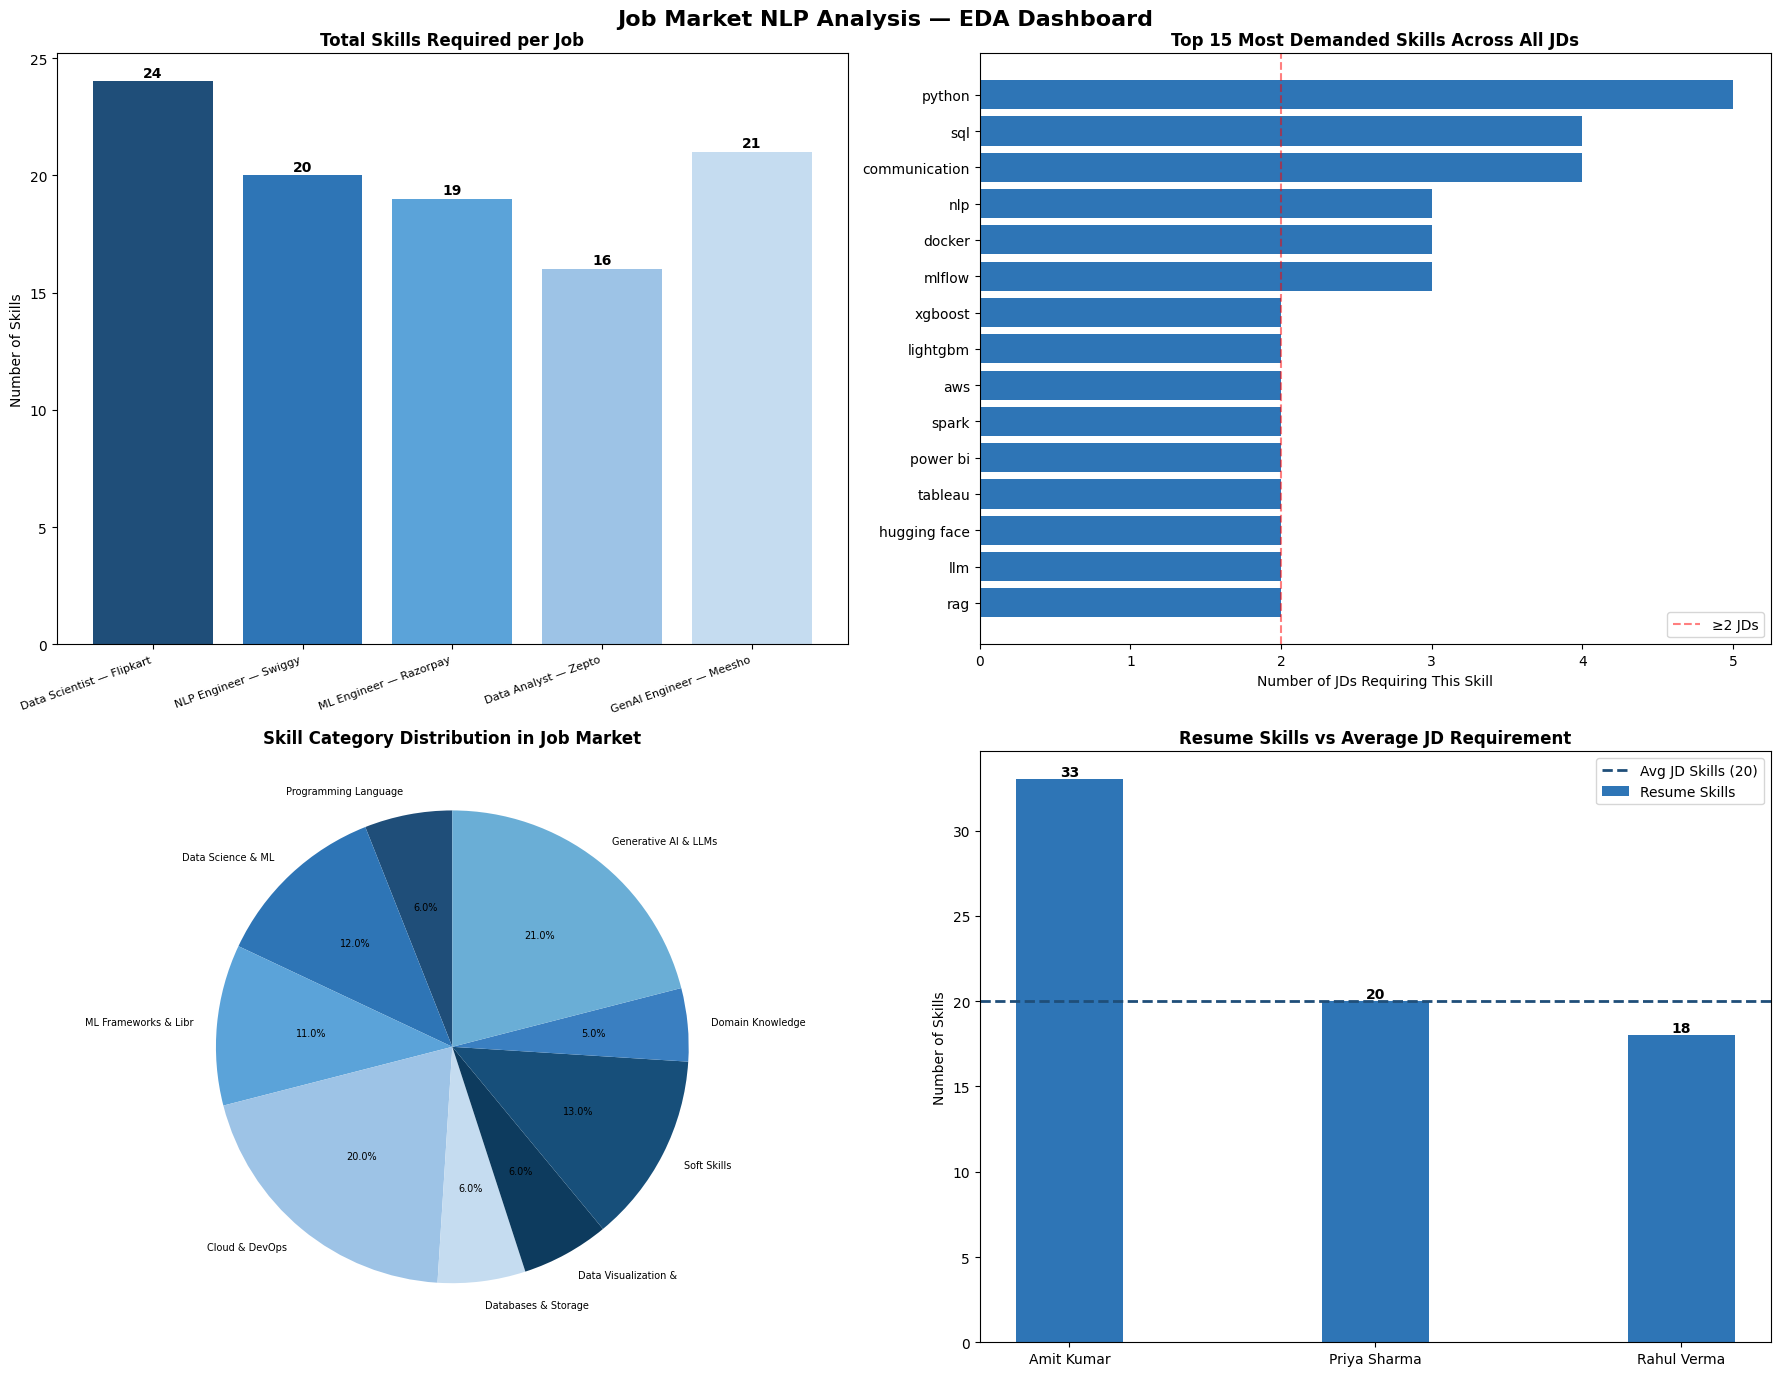

✅ EDA visualization saved


In [11]:
# ── EDA Visualization 1: Skill category distribution across JDs ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Job Market NLP Analysis — EDA Dashboard', fontsize=16, fontweight='bold')

colors = ['#1F4E79','#2E75B6','#5BA3D9','#9DC3E6','#C5DCF0',
          '#0D3B5E','#174F7A','#3A7FC1','#6AAED6','#B8D4EA']

# 1. Skills per JD
jd_names = [job_descriptions[jd]['title'][:25] for jd in jd_skills]
jd_counts = [len(skills) for skills in jd_skills.values()]
bars = axes[0][0].bar(range(len(jd_names)), jd_counts, color=colors[:len(jd_names)])
axes[0][0].set_xticks(range(len(jd_names)))
axes[0][0].set_xticklabels(jd_names, rotation=20, ha='right', fontsize=8)
axes[0][0].set_title('Total Skills Required per Job', fontweight='bold')
axes[0][0].set_ylabel('Number of Skills')
for bar, v in zip(bars, jd_counts):
    axes[0][0].text(bar.get_x()+bar.get_width()/2., v+0.2, str(v), ha='center', fontweight='bold')

# 2. Most demanded skills across all JDs
all_demanded = Counter()
for skills in jd_skills.values():
    for skill in skills:
        all_demanded[skill] += 1
top_skills = all_demanded.most_common(15)
skill_names, skill_freqs = zip(*top_skills)
axes[0][1].barh(list(reversed(skill_names)), list(reversed(skill_freqs)), color='#2E75B6')
axes[0][1].set_title('Top 15 Most Demanded Skills Across All JDs', fontweight='bold')
axes[0][1].set_xlabel('Number of JDs Requiring This Skill')
axes[0][1].axvline(x=2, color='red', linestyle='--', alpha=0.5, label='≥2 JDs')
axes[0][1].legend()

# 3. Skill category distribution
all_categories = Counter()
for skills in jd_skills.values():
    for cat in skills.values():
        all_categories[cat] += 1
cat_names = list(all_categories.keys())
cat_vals  = list(all_categories.values())
wedges, texts, autotexts = axes[1][0].pie(
    cat_vals, labels=[c[:20] for c in cat_names],
    autopct='%1.1f%%', colors=colors[:len(cat_names)],
    startangle=90, textprops={'fontsize': 7}
)
axes[1][0].set_title('Skill Category Distribution in Job Market', fontweight='bold')

# 4. Resume vs JD skill count comparison
res_names  = [resumes[r]['name'] for r in resume_skills]
res_counts = [len(skills) for skills in resume_skills.values()]
x = np.arange(len(res_names))
width = 0.35
avg_jd_skills = np.mean(jd_counts)
axes[1][1].bar(x, res_counts, width, label='Resume Skills', color='#2E75B6')
axes[1][1].axhline(y=avg_jd_skills, color='#1F4E79', linestyle='--',
                    linewidth=2, label=f'Avg JD Skills ({avg_jd_skills:.0f})')
axes[1][1].set_xticks(x)
axes[1][1].set_xticklabels(res_names)
axes[1][1].set_title('Resume Skills vs Average JD Requirement', fontweight='bold')
axes[1][1].set_ylabel('Number of Skills')
axes[1][1].legend()
for i, v in enumerate(res_counts):
    axes[1][1].text(i, v+0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA visualization saved")

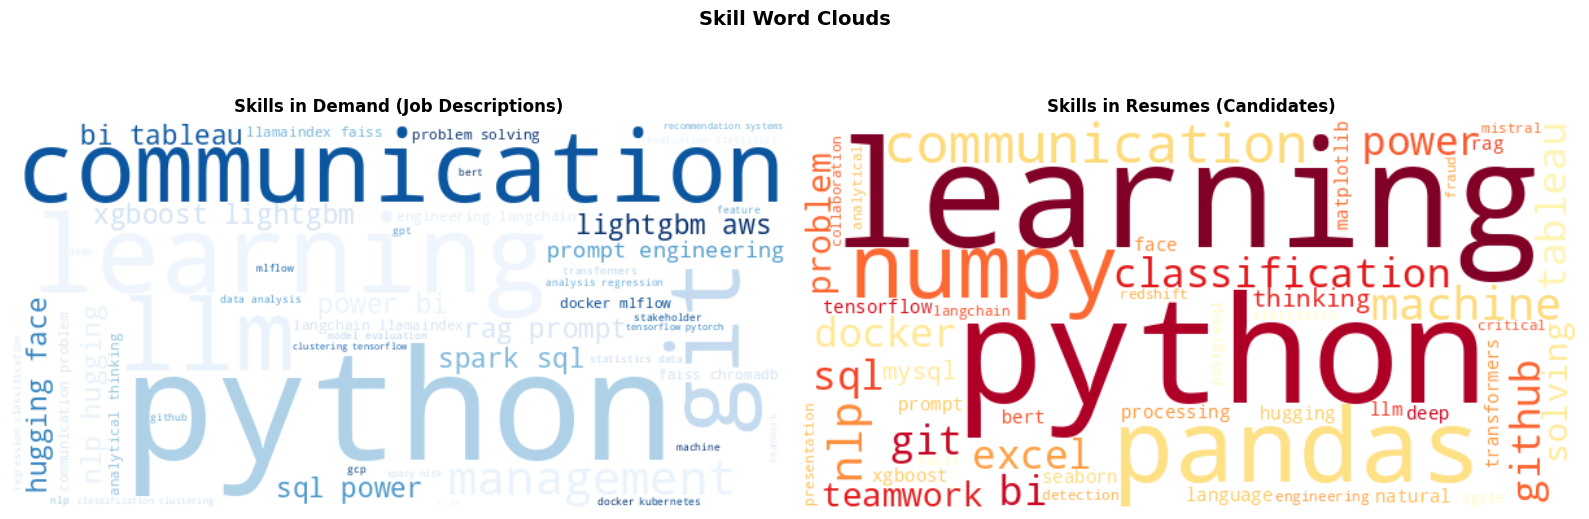

In [12]:
# ── Word Cloud of Top Skills ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Skill Word Clouds', fontsize=14, fontweight='bold')

# JD skills wordcloud
jd_skill_text = ' '.join([' '.join(list(skills.keys()) * freq)
                           for skills, freq in zip(jd_skills.values(), [3]*5)])
wc_jd = WordCloud(width=600, height=300, background_color='white',
                   colormap='Blues', max_words=50).generate(jd_skill_text)
axes[0].imshow(wc_jd, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Skills in Demand (Job Descriptions)', fontweight='bold', fontsize=12)

# Resume skills wordcloud
res_skill_text = ' '.join([' '.join(list(skills.keys()))
                            for skills in resume_skills.values()])
wc_res = WordCloud(width=600, height=300, background_color='white',
                    colormap='YlOrRd', max_words=50).generate(res_skill_text)
axes[1].imshow(wc_res, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Skills in Resumes (Candidates)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('skill_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Step 7 — Resume-JD Matching Engine
### Two matching methods:
1. **TF-IDF + Cosine Similarity** — keyword overlap based
2. **Semantic Similarity** — meaning-based using SentenceTransformer

In [13]:
def compute_tfidf_score(jd_text, resume_text):
    """Compute TF-IDF cosine similarity between JD and Resume."""
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),      # unigrams + bigrams
        stop_words='english',
        max_features=5000,
        min_df=1
    )
    jd_clean     = preprocess_text(jd_text)
    resume_clean = preprocess_text(resume_text)
    tfidf_matrix = vectorizer.fit_transform([jd_clean, resume_clean])
    score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    return round(float(score) * 100, 2)

def compute_semantic_score(jd_text, resume_text):
    """Compute semantic similarity using SentenceTransformer embeddings."""
    jd_emb  = semantic_model.encode(jd_text[:1000], convert_to_tensor=False)
    res_emb = semantic_model.encode(resume_text[:1000], convert_to_tensor=False)
    jd_emb  = jd_emb.reshape(1, -1)
    res_emb = res_emb.reshape(1, -1)
    score   = cosine_similarity(jd_emb, res_emb)[0][0]
    return round(float(score) * 100, 2)

def compute_skill_overlap(jd_skills_dict, resume_skills_dict):
    """Compute skill-level match analysis."""
    jd_set     = set(jd_skills_dict.keys())
    resume_set = set(resume_skills_dict.keys())
    matching   = jd_set & resume_set
    missing    = jd_set - resume_set
    extra      = resume_set - jd_set
    skill_score = round(len(matching) / len(jd_set) * 100, 2) if jd_set else 0
    return {
        'matching_skills' : sorted(list(matching)),
        'missing_skills'  : sorted(list(missing)),
        'extra_skills'    : sorted(list(extra)),
        'skill_match_pct' : skill_score,
        'total_jd_skills' : len(jd_set),
        'total_res_skills': len(resume_set),
        'matched_count'   : len(matching),
        'missing_count'   : len(missing)
    }

def final_match_score(tfidf_score, semantic_score, skill_score):
    """Weighted final score: 30% TF-IDF + 40% Semantic + 30% Skill overlap."""
    return round(0.30 * tfidf_score + 0.40 * semantic_score + 0.30 * skill_score, 2)

print("✅ Matching engine ready!")
print("\nFormula: Final Score = 30% TF-IDF + 40% Semantic + 30% Skill Overlap")

✅ Matching engine ready!

Formula: Final Score = 30% TF-IDF + 40% Semantic + 30% Skill Overlap


In [14]:
# ── Run Matching: All Resumes vs All JDs ──
print("🔍 Running Resume-JD Matching...\n")
print("="*70)

all_results = []

for res_id, resume in resumes.items():
    print(f"\n👤 Candidate: {resume['name']}")
    print("-"*50)

    for jd_id, jd in job_descriptions.items():
        # Compute all scores
        tfidf_s  = compute_tfidf_score(jd['text'], resume['text'])
        sem_s    = compute_semantic_score(jd['text'], resume['text'])
        overlap  = compute_skill_overlap(jd_skills[jd_id], resume_skills[res_id])
        skill_s  = overlap['skill_match_pct']
        final_s  = final_match_score(tfidf_s, sem_s, skill_s)

        result = {
            'candidate'      : resume['name'],
            'resume_id'      : res_id,
            'job_title'      : jd['title'],
            'jd_id'          : jd_id,
            'tfidf_score'    : tfidf_s,
            'semantic_score' : sem_s,
            'skill_score'    : skill_s,
            'final_score'    : final_s,
            'matching_skills': overlap['matching_skills'],
            'missing_skills' : overlap['missing_skills'],
            'matched_count'  : overlap['matched_count'],
            'missing_count'  : overlap['missing_count'],
            'total_jd_skills': overlap['total_jd_skills']
        }
        all_results.append(result)

        # Color code based on score
        status = "🟢 STRONG" if final_s >= 60 else "🟡 MODERATE" if final_s >= 40 else "🔴 WEAK"
        print(f"  {status} | {jd['title'][:35]:35s} | Score: {final_s:5.1f}% "
              f"[TF-IDF:{tfidf_s:.1f} Sem:{sem_s:.1f} Skill:{skill_s:.1f}]")

results_df = pd.DataFrame(all_results)
print("\n✅ Matching complete!")

🔍 Running Resume-JD Matching...


👤 Candidate: Amit Kumar
--------------------------------------------------
  🟡 MODERATE | Data Scientist — Flipkart           | Score:  43.8% [TF-IDF:13.7 Sem:64.9 Skill:45.8]
  🟡 MODERATE | NLP Engineer — Swiggy               | Score:  48.3% [TF-IDF:17.3 Sem:55.4 Skill:70.0]
  🔴 WEAK | ML Engineer — Razorpay              | Score:  38.9% [TF-IDF:11.8 Sem:64.7 Skill:31.6]
  🟡 MODERATE | Data Analyst — Zepto                | Score:  45.3% [TF-IDF:14.2 Sem:55.6 Skill:62.5]
  🟡 MODERATE | GenAI Engineer — Meesho             | Score:  51.5% [TF-IDF:14.4 Sem:64.3 Skill:71.4]

👤 Candidate: Priya Sharma
--------------------------------------------------
  🔴 WEAK | Data Scientist — Flipkart           | Score:  35.3% [TF-IDF:14.0 Sem:58.9 Skill:25.0]
  🔴 WEAK | NLP Engineer — Swiggy               | Score:  21.6% [TF-IDF:6.7 Sem:37.7 Skill:15.0]
  🔴 WEAK | ML Engineer — Razorpay              | Score:  30.7% [TF-IDF:9.2 Sem:50.2 Skill:26.3]
  🟡 MODERATE | Data Ana

## 📊 Step 8 — Match Score Visualization

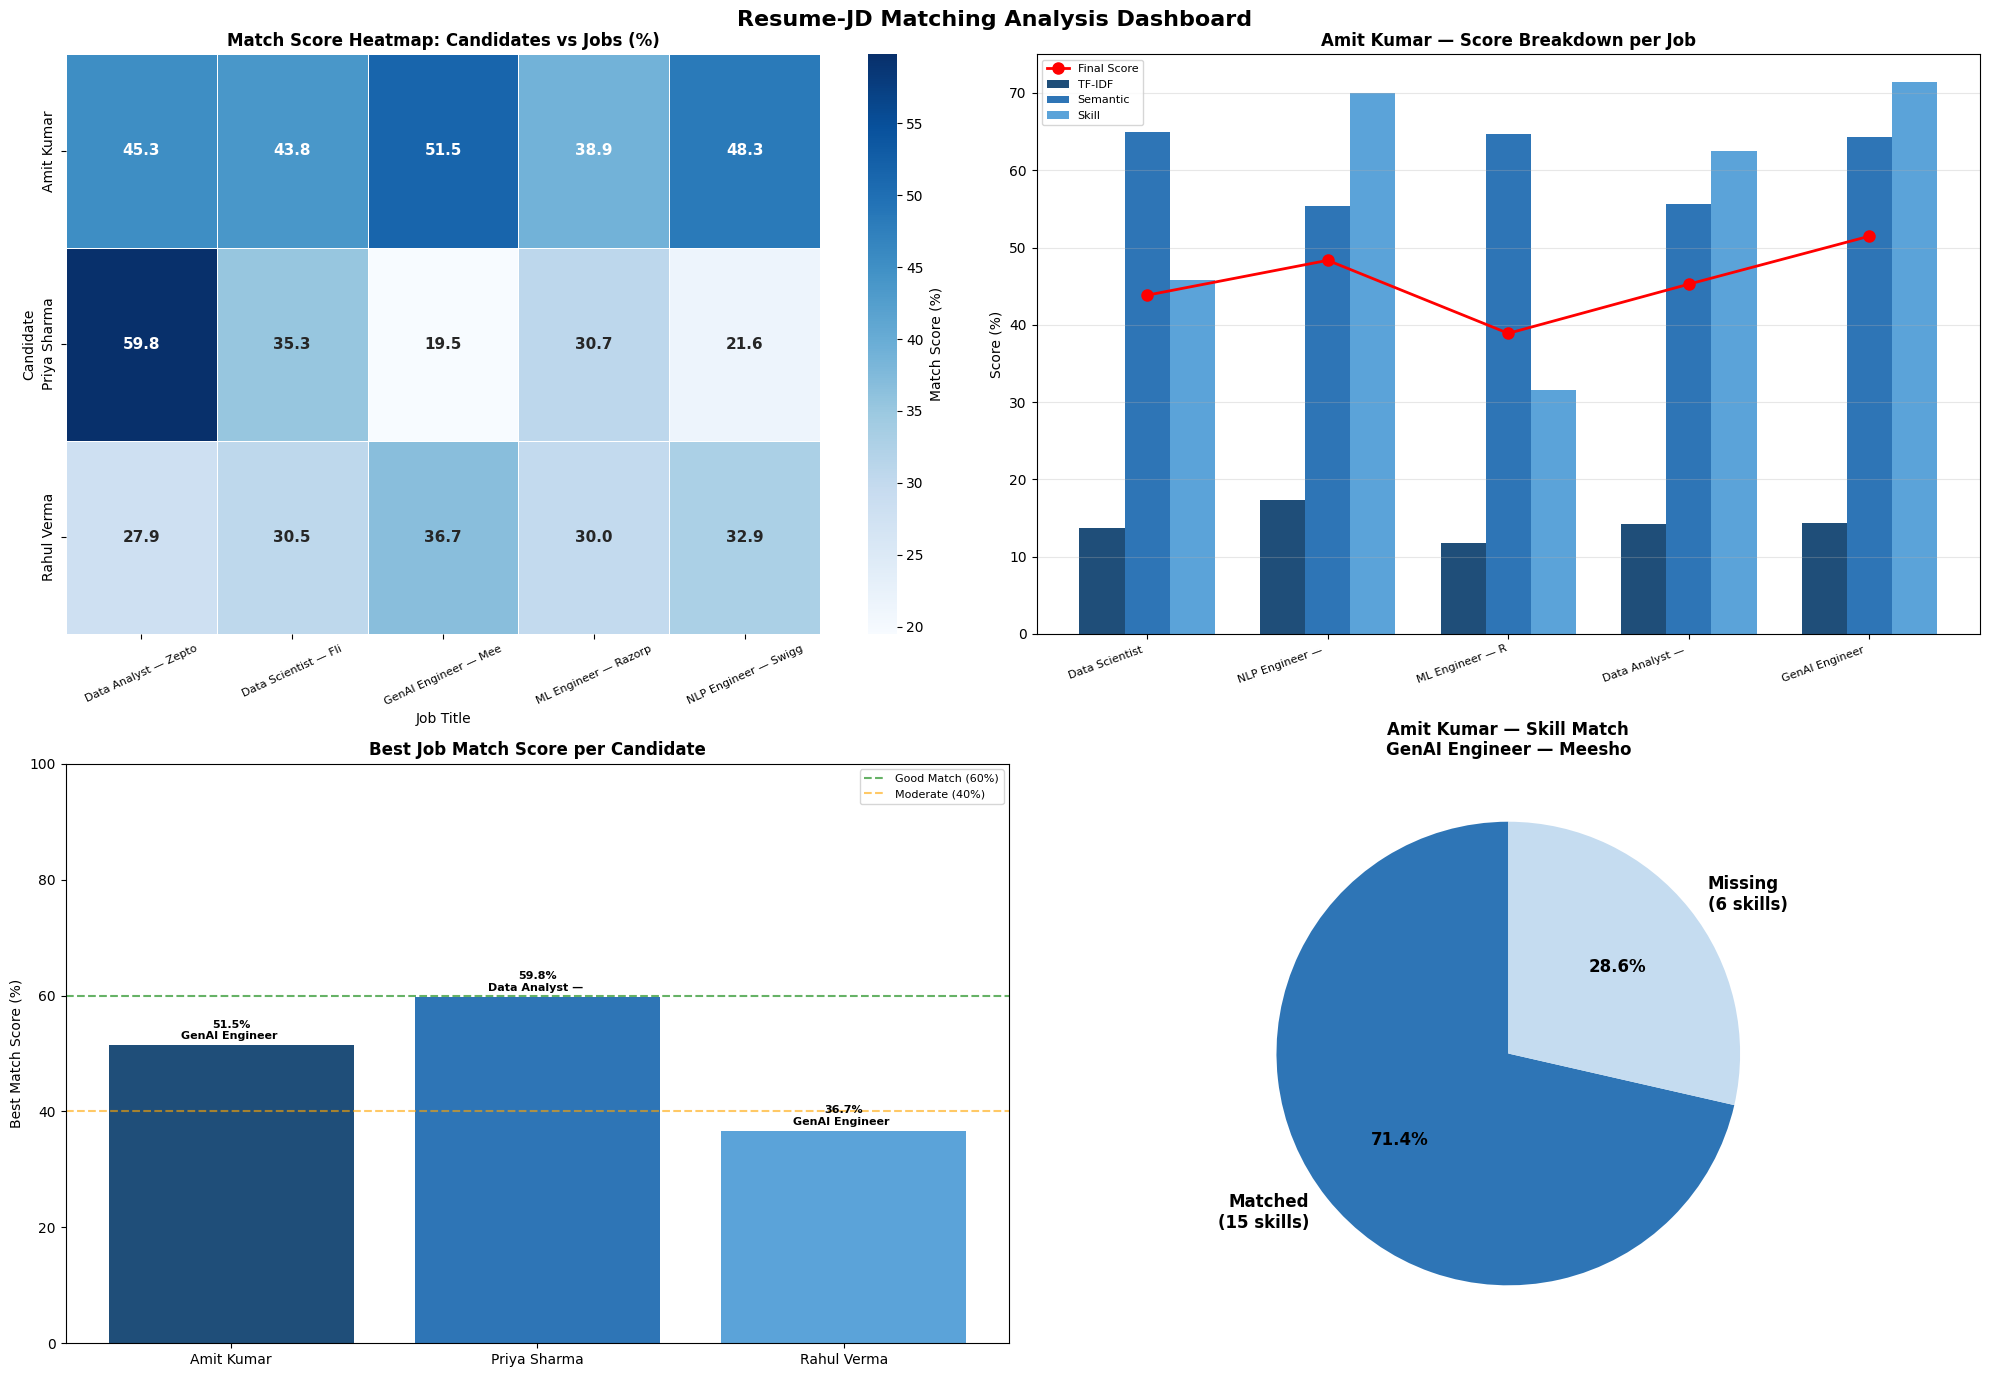

In [15]:
# ── Heatmap: All candidates vs all JDs ──
pivot_df = results_df.pivot(index='candidate', columns='job_title', values='final_score')
pivot_df.columns = [c[:20] for c in pivot_df.columns]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Resume-JD Matching Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Heatmap
sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[0][0], linewidths=0.5,
            cbar_kws={'label': 'Match Score (%)'},
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0][0].set_title('Match Score Heatmap: Candidates vs Jobs (%)', fontweight='bold')
axes[0][0].set_xlabel('Job Title')
axes[0][0].set_ylabel('Candidate')
axes[0][0].tick_params(axis='x', rotation=25, labelsize=8)

# 2. Score breakdown for Amit on all JDs
amit_df = results_df[results_df['candidate'] == 'Amit Kumar'].copy()
x = np.arange(len(amit_df))
w = 0.25
axes[0][1].bar(x - w,   amit_df['tfidf_score'],    w, label='TF-IDF',   color='#1F4E79')
axes[0][1].bar(x,       amit_df['semantic_score'],  w, label='Semantic', color='#2E75B6')
axes[0][1].bar(x + w,   amit_df['skill_score'],     w, label='Skill',    color='#5BA3D9')
axes[0][1].plot(x, amit_df['final_score'], 'ro-', linewidth=2, markersize=8, label='Final Score', zorder=5)
axes[0][1].set_xticks(x)
axes[0][1].set_xticklabels([t[:15] for t in amit_df['job_title']], rotation=20, ha='right', fontsize=8)
axes[0][1].set_title('Amit Kumar — Score Breakdown per Job', fontweight='bold')
axes[0][1].set_ylabel('Score (%)')
axes[0][1].legend(fontsize=8)
axes[0][1].grid(axis='y', alpha=0.3)

# 3. Top matches per candidate
top_matches = results_df.loc[results_df.groupby('candidate')['final_score'].idxmax()]
colors_bar = ['#1F4E79', '#2E75B6', '#5BA3D9']
bars = axes[1][0].bar(top_matches['candidate'], top_matches['final_score'], color=colors_bar)
axes[1][0].set_title('Best Job Match Score per Candidate', fontweight='bold')
axes[1][0].set_ylabel('Best Match Score (%)')
axes[1][0].set_ylim(0, 100)
for bar, (_, row) in zip(bars, top_matches.iterrows()):
    axes[1][0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+1,
                    f"{row['final_score']:.1f}%\n{row['job_title'][:15]}",
                    ha='center', fontsize=8, fontweight='bold')
axes[1][0].axhline(y=60, color='green', linestyle='--', alpha=0.6, label='Good Match (60%)')
axes[1][0].axhline(y=40, color='orange', linestyle='--', alpha=0.6, label='Moderate (40%)')
axes[1][0].legend(fontsize=8)

# 4. Skill matching vs missing for Amit's best JD
best_jd_id = amit_df.loc[amit_df['final_score'].idxmax(), 'jd_id']
best_jd_row = amit_df.loc[amit_df['final_score'].idxmax()]
matched_count = best_jd_row['matched_count']
missing_count = best_jd_row['missing_count']
axes[1][1].pie([matched_count, missing_count],
               labels=[f"Matched\n({matched_count} skills)", f"Missing\n({missing_count} skills)"],
               colors=['#2E75B6', '#C5DCF0'], autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1][1].set_title(f"Amit Kumar — Skill Match\n{best_jd_row['job_title'][:40]}",
                      fontweight='bold')

plt.tight_layout()
plt.savefig('match_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Step 9 — Gap Analysis & Career Recommendations

In [16]:
def print_gap_analysis(candidate_name, jd_title, result_row):
    """Print detailed gap analysis for a candidate-JD pair."""
    print("="*65)
    print(f"  GAP ANALYSIS REPORT")
    print("="*65)
    print(f"  Candidate : {candidate_name}")
    print(f"  Job       : {jd_title}")
    print(f"  Final Score: {result_row['final_score']:.1f}%", end="  ")

    if result_row['final_score'] >= 60:
        print("🟢 STRONG MATCH — Apply with confidence!")
    elif result_row['final_score'] >= 40:
        print("🟡 MODERATE — Some upskilling needed")
    else:
        print("🔴 WEAK — Significant gaps to bridge")

    print(f"\n  Score Breakdown:")
    print(f"    TF-IDF Score    : {result_row['tfidf_score']:.1f}%")
    print(f"    Semantic Score  : {result_row['semantic_score']:.1f}%")
    print(f"    Skill Score     : {result_row['skill_score']:.1f}%")

    print(f"\n  ✅ Matching Skills ({result_row['matched_count']}):")
    for skill in result_row['matching_skills']:
        print(f"     + {skill}")

    print(f"\n  ❌ Missing Skills ({result_row['missing_count']}) — Upskill These:")
    for skill in result_row['missing_skills']:
        print(f"     - {skill}")
    print("="*65)

# Print gap analysis for Amit on his best matching JD
amit_results = results_df[results_df['candidate'] == 'Amit Kumar']
best_row = amit_results.loc[amit_results['final_score'].idxmax()]
print_gap_analysis('Amit Kumar', best_row['job_title'], best_row)

  GAP ANALYSIS REPORT
  Candidate : Amit Kumar
  Job       : GenAI Engineer — Meesho
  Final Score: 51.5%  🟡 MODERATE — Some upskilling needed

  Score Breakdown:
    TF-IDF Score    : 14.4%
    Semantic Score  : 64.3%
    Skill Score     : 71.4%

  ✅ Matching Skills (15):
     + communication
     + docker
     + faiss
     + git
     + github
     + hugging face
     + langchain
     + llm
     + mistral
     + nlp
     + prompt engineering
     + python
     + rag
     + teamwork
     + transformers

  ❌ Missing Skills (6) — Upskill These:
     - chromadb
     - embeddings
     - gpt
     - llama
     - llamaindex
     - mlflow


In [17]:
# ── Rank All Candidates for Each JD ──
print("\n📋 CANDIDATE RANKING PER JOB\n")
for jd_id, jd in job_descriptions.items():
    jd_results = results_df[results_df['jd_id'] == jd_id].sort_values('final_score', ascending=False)
    print(f"\n🏢 {jd['title']}")
    print(f"   {'Rank':<6} {'Candidate':<20} {'Score':>8} {'Matched':>10} {'Missing':>10}")
    print(f"   {'-'*55}")
    for rank, (_, row) in enumerate(jd_results.iterrows(), 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉"
        print(f"   {medal} #{rank}  {row['candidate']:<20} {row['final_score']:>7.1f}%"
              f"   {row['matched_count']:>5} skills   {row['missing_count']:>5} missing")


📋 CANDIDATE RANKING PER JOB


🏢 Data Scientist — Flipkart
   Rank   Candidate               Score    Matched    Missing
   -------------------------------------------------------
   🥇 #1  Amit Kumar              43.8%      11 skills      13 missing
   🥈 #2  Priya Sharma            35.3%       6 skills      18 missing
   🥉 #3  Rahul Verma             30.5%       6 skills      18 missing

🏢 NLP Engineer — Swiggy
   Rank   Candidate               Score    Matched    Missing
   -------------------------------------------------------
   🥇 #1  Amit Kumar              48.3%      14 skills       6 missing
   🥈 #2  Rahul Verma             32.9%       6 skills      14 missing
   🥉 #3  Priya Sharma            21.6%       3 skills      17 missing

🏢 ML Engineer — Razorpay
   Rank   Candidate               Score    Matched    Missing
   -------------------------------------------------------
   🥇 #1  Amit Kumar              38.9%       6 skills      13 missing
   🥈 #2  Priya Sharma            30.7

## 📈 Step 10 — Skill Gap Visualization

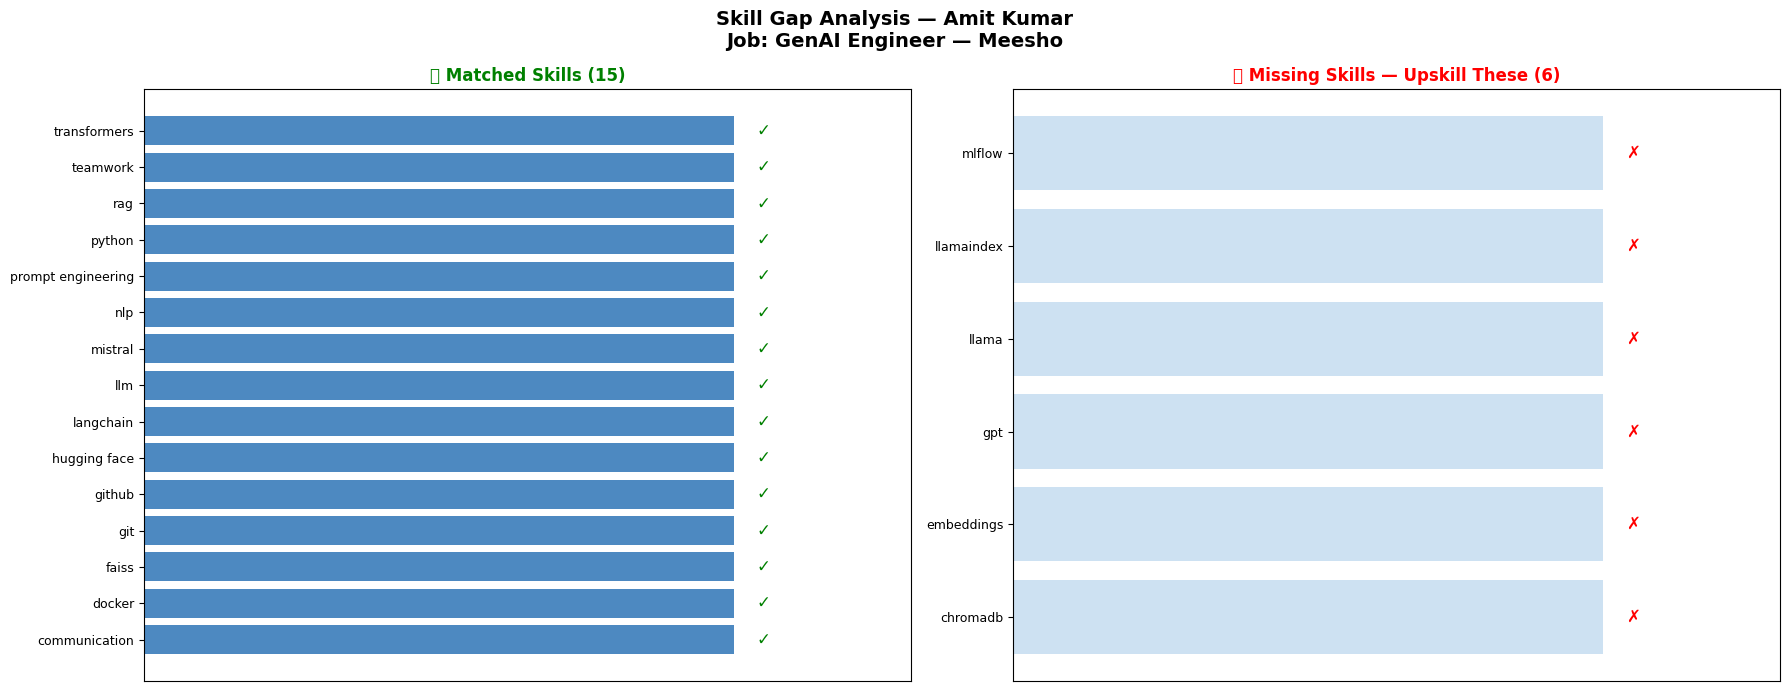

In [18]:
# Best match row for Amit
amit_best = results_df[(results_df['candidate']=='Amit Kumar')].copy()
amit_best = amit_best.sort_values('final_score', ascending=False).iloc[0]

matched = amit_best['matching_skills']
missing = amit_best['missing_skills']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f"Skill Gap Analysis — Amit Kumar\nJob: {amit_best['job_title']}",
             fontsize=14, fontweight='bold')

# Matched skills
if matched:
    axes[0].barh(range(len(matched)), [1]*len(matched), color='#2E75B6', alpha=0.85)
    axes[0].set_yticks(range(len(matched)))
    axes[0].set_yticklabels(matched, fontsize=9)
    axes[0].set_title(f'✅ Matched Skills ({len(matched)})', fontweight='bold', color='green')
    axes[0].set_xlim(0, 1.3)
    axes[0].set_xticks([])
    for i in range(len(matched)):
        axes[0].text(1.05, i, '✓', ha='center', va='center',
                     fontsize=12, color='green', fontweight='bold')

# Missing skills
if missing:
    axes[1].barh(range(len(missing)), [1]*len(missing), color='#C5DCF0', alpha=0.85)
    axes[1].set_yticks(range(len(missing)))
    axes[1].set_yticklabels(missing, fontsize=9)
    axes[1].set_title(f'❌ Missing Skills — Upskill These ({len(missing)})',
                       fontweight='bold', color='red')
    axes[1].set_xlim(0, 1.3)
    axes[1].set_xticks([])
    for i in range(len(missing)):
        axes[1].text(1.05, i, '✗', ha='center', va='center',
                     fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('skill_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 🚀 Step 11 — Full Pipeline: Paste Any JD + Resume → Get Score

In [19]:
def analyze_resume_for_job(jd_text, resume_text, candidate_name="Candidate", job_name="Job"):
    """
    Complete pipeline: input any JD + Resume text → get full analysis.
    This is what the Streamlit app uses.
    """
    print("="*65)
    print("  RESUME-JD MATCH ANALYSIS")
    print("="*65)

    # Extract skills
    jd_s  = extract_skills_from_text(jd_text)
    res_s = extract_skills_from_text(resume_text)

    # Compute scores
    tfidf_s  = compute_tfidf_score(jd_text, resume_text)
    sem_s    = compute_semantic_score(jd_text, resume_text)
    overlap  = compute_skill_overlap(jd_s, res_s)
    skill_s  = overlap['skill_match_pct']
    final_s  = final_match_score(tfidf_s, sem_s, skill_s)

    # Verdict
    if final_s >= 65:
        verdict = "🟢 STRONG MATCH — Apply now!"
        rec = "Your profile is well-aligned. Highlight matching skills in your cover letter."
    elif final_s >= 45:
        verdict = "🟡 MODERATE MATCH — Apply with upskilling"
        rec = f"Learn {', '.join(overlap['missing_skills'][:3])} to strengthen your profile."
    else:
        verdict = "🔴 WEAK MATCH — Significant gaps"
        rec = f"Focus on building: {', '.join(overlap['missing_skills'][:5])}"

    print(f"  Candidate : {candidate_name}")
    print(f"  Job       : {job_name}")
    print(f"\n  FINAL SCORE : {final_s:.1f}%   {verdict}")
    print(f"\n  Score Breakdown:")
    print(f"    Keyword Match (TF-IDF)  : {tfidf_s:.1f}%")
    print(f"    Semantic Similarity      : {sem_s:.1f}%")
    print(f"    Skill Overlap            : {skill_s:.1f}%")
    print(f"\n  Skill Summary:")
    print(f"    JD requires   : {len(jd_s)} skills")
    print(f"    Resume has    : {len(res_s)} skills")
    print(f"    Matched       : {overlap['matched_count']} skills ✅")
    print(f"    Missing       : {overlap['missing_count']} skills ❌")
    print(f"\n  💡 Recommendation: {rec}")
    print(f"\n  ✅ Your Matching Skills:")
    print(f"     {', '.join(overlap['matching_skills'][:8])}")
    print(f"\n  ❌ Skills to Add:")
    print(f"     {', '.join(overlap['missing_skills'][:8])}")
    print("="*65)

    return final_s, overlap

# ── LIVE DEMO ──
custom_jd = """
We are looking for a Data Scientist with strong Python skills,
experience in machine learning, NLP, and SQL. Must know scikit-learn,
XGBoost, pandas, matplotlib. Experience with AWS and Docker preferred.
Good communication and teamwork skills required.
"""

custom_resume = """
Data Scientist with 2 years experience. Skills: Python, machine learning,
NLP, pandas, numpy, scikit-learn, SQL, matplotlib, seaborn.
Built ML pipelines for classification and regression. Good at teamwork.
"""

score, gap = analyze_resume_for_job(
    custom_jd, custom_resume,
    candidate_name="Demo Candidate",
    job_name="Data Scientist Role"
)

  RESUME-JD MATCH ANALYSIS
  Candidate : Demo Candidate
  Job       : Data Scientist Role

  FINAL SCORE : 59.8%   🟡 MODERATE MATCH — Apply with upskilling

  Score Breakdown:
    Keyword Match (TF-IDF)  : 27.3%
    Semantic Similarity      : 81.3%
    Skill Overlap            : 63.6%

  Skill Summary:
    JD requires   : 11 skills
    Resume has    : 11 skills
    Matched       : 7 skills ✅
    Missing       : 4 skills ❌

  💡 Recommendation: Learn aws, communication, docker to strengthen your profile.

  ✅ Your Matching Skills:
     machine learning, matplotlib, nlp, pandas, python, sql, teamwork

  ❌ Skills to Add:
     aws, communication, docker, xgboost


## 📊 Step 12 — Model Evaluation & Performance Analysis

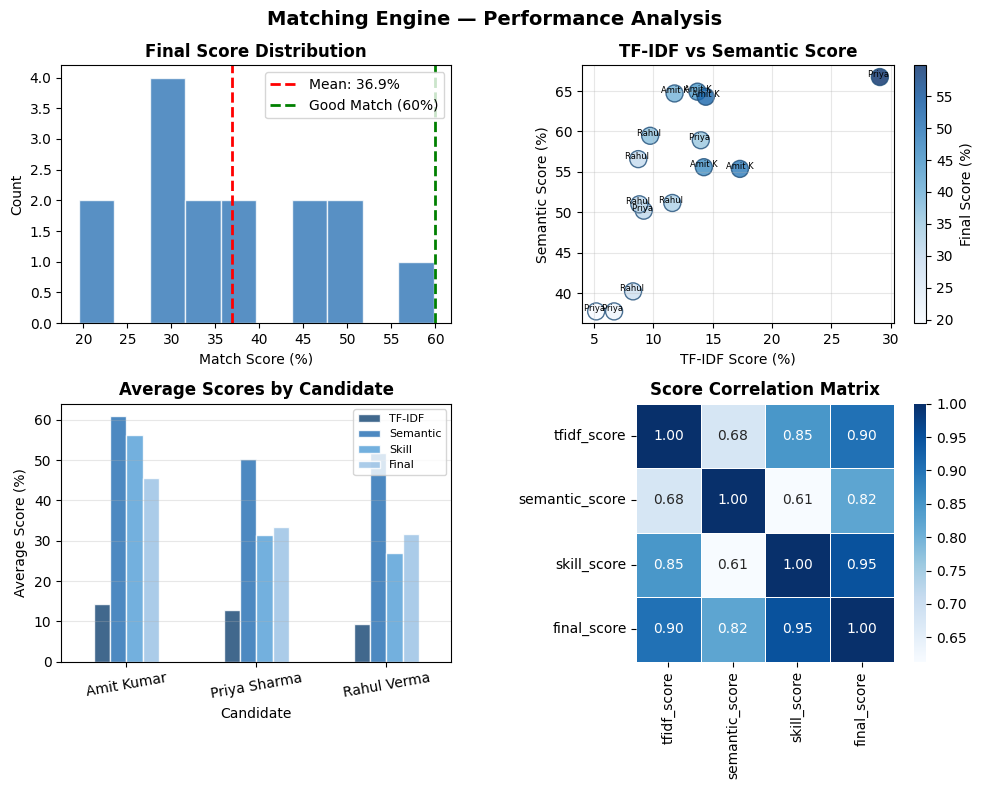


📊 Summary Statistics:
       tfidf_score  semantic_score  skill_score  final_score
count        15.00           15.00        15.00        15.00
mean         12.18           54.31        38.25        36.85
std           5.73            9.70        22.60        11.18
min           5.17           37.73         9.52        19.50
25%           8.76           50.60        25.00        30.26
50%          11.59           55.58        31.25        35.27
75%          14.12           61.88        54.16        44.54
max          29.09           66.74        81.25        59.80


In [22]:
# ── Score Distribution Analysis ──
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Matching Engine — Performance Analysis', fontsize=14, fontweight='bold')

# 1. Score distribution
axes[0][0].hist(results_df['final_score'], bins=10, color='#2E75B6', alpha=0.8, edgecolor='white')
axes[0][0].axvline(results_df['final_score'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Mean: {results_df['final_score'].mean():.1f}%")
axes[0][0].axvline(60, color='green', linestyle='--', linewidth=2, label='Good Match (60%)')
axes[0][0].set_title('Final Score Distribution', fontweight='bold')
axes[0][0].set_xlabel('Match Score (%)')
axes[0][0].set_ylabel('Count')
axes[0][0].legend()

# 2. TF-IDF vs Semantic score scatter
scatter = axes[0][1].scatter(results_df['tfidf_score'], results_df['semantic_score'],
                              c=results_df['final_score'], cmap='Blues',
                              s=150, alpha=0.8, edgecolors='#1F4E79', linewidths=1)
plt.colorbar(scatter, ax=axes[0][1], label='Final Score (%)')
for _, row in results_df.iterrows():
    axes[0][1].annotate(row['candidate'][:6],
                        (row['tfidf_score'], row['semantic_score']),
                        fontsize=6, ha='center')
axes[0][1].set_title('TF-IDF vs Semantic Score', fontweight='bold')
axes[0][1].set_xlabel('TF-IDF Score (%)')
axes[0][1].set_ylabel('Semantic Score (%)')
axes[0][1].grid(alpha=0.3)

# 3. Average scores by candidate
avg_by_candidate = results_df.groupby('candidate')[['tfidf_score','semantic_score','skill_score','final_score']].mean()
avg_by_candidate.plot(kind='bar', ax=axes[1][0], color=['#1F4E79','#2E75B6','#5BA3D9','#9DC3E6'],
                       alpha=0.85, edgecolor='white')
axes[1][0].set_title('Average Scores by Candidate', fontweight='bold')
axes[1][0].set_xlabel('Candidate')
axes[1][0].set_ylabel('Average Score (%)')
axes[1][0].legend(['TF-IDF','Semantic','Skill','Final'], fontsize=8)
axes[1][0].tick_params(axis='x', rotation=10)
axes[1][0].grid(axis='y', alpha=0.3)

# 4. Score correlation heatmap
corr = results_df[['tfidf_score','semantic_score','skill_score','final_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=axes[1][1],
            linewidths=0.5, square=True)
axes[1][1].set_title('Score Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Summary Statistics:")
print(results_df[['tfidf_score','semantic_score','skill_score','final_score']].describe().round(2))

## 🌐 Step 13 — Streamlit App Code

In [ ]:
streamlit_app = '''
import streamlit as st
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import spacy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

st.set_page_config(page_title="Resume Matcher", page_icon="💼", layout="wide")
st.title("💼 Job Description Skill Extractor + Resume Matcher")
st.caption("NLP-powered Resume Screening Tool | By Amit Kumar")

SKILL_TAXONOMY = {
    "Programming": ["python","java","javascript","r","scala","c++","sql","bash"],
    "ML & AI": ["machine learning","deep learning","nlp","natural language processing",
                "computer vision","feature engineering","classification","regression","clustering"],
    "Frameworks": ["tensorflow","pytorch","scikit-learn","xgboost","hugging face",
                   "transformers","spacy","langchain","fastapi"],
    "Cloud & DevOps": ["aws","azure","gcp","docker","kubernetes","git","mlflow","airflow"],
    "Visualization": ["power bi","tableau","excel","matplotlib","plotly","seaborn"],
    "Soft Skills": ["communication","teamwork","leadership","problem solving","agile","scrum"]
}
ALL_SKILLS = {s.lower(): cat for cat, skills in SKILL_TAXONOMY.items() for s in skills}

@st.cache_resource
def load_models():
    model = SentenceTransformer("all-MiniLM-L6-v2")
    nlp   = spacy.load("en_core_web_sm")
    return model, nlp

sem_model, nlp = load_models()

def extract_skills(text):
    text_l = text.lower()
    found  = {}
    for skill, cat in ALL_SKILLS.items():
        if re.search(r"\b" + re.escape(skill) + r"\b", text_l):
            found[skill] = cat
    return found

def match_score(jd_text, res_text):
    vec   = TfidfVectorizer(ngram_range=(1,2), stop_words="english")
    mat   = vec.fit_transform([jd_text.lower(), res_text.lower()])
    tfidf = round(float(cosine_similarity(mat[0:1], mat[1:2])[0][0]) * 100, 1)
    j_emb = sem_model.encode(jd_text[:800]).reshape(1,-1)
    r_emb = sem_model.encode(res_text[:800]).reshape(1,-1)
    sem   = round(float(cosine_similarity(j_emb, r_emb)[0][0]) * 100, 1)
    jd_s  = set(extract_skills(jd_text))
    re_s  = set(extract_skills(res_text))
    skill = round(len(jd_s & re_s) / max(len(jd_s), 1) * 100, 1)
    final = round(0.3*tfidf + 0.4*sem + 0.3*skill, 1)
    matching = sorted(list(jd_s & re_s))
    missing  = sorted(list(jd_s - re_s))
    return tfidf, sem, skill, final, matching, missing

col1, col2 = st.columns(2)
with col1:
    jd_text  = st.text_area("📋 Paste Job Description:", height=300,
                              placeholder="Paste JD here...")
with col2:
    res_text = st.text_area("📄 Paste Your Resume:", height=300,
                              placeholder="Paste resume text here...")

if st.button("🚀 Analyze Match", type="primary") and jd_text and res_text:
    with st.spinner("Analyzing..."):
        tfidf_s, sem_s, skill_s, final_s, matched, missing = match_score(jd_text, res_text)

    # Score display
    st.markdown("---")
    st.subheader("📊 Match Analysis Results")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("🎯 Final Score",    f"{final_s}%")
    col2.metric("🔤 Keyword Match",  f"{tfidf_s}%")
    col3.metric("🧠 Semantic Match", f"{sem_s}%")
    col4.metric("⚙️ Skill Match",    f"{skill_s}%")

    # Verdict
    if final_s >= 65:
        st.success("🟢 STRONG MATCH — Apply with confidence!")
    elif final_s >= 45:
        st.warning("🟡 MODERATE MATCH — Some upskilling needed")
    else:
        st.error("🔴 WEAK MATCH — Significant skill gaps")

    # Skill breakdown
    col_a, col_b = st.columns(2)
    with col_a:
        st.subheader(f"✅ Matched Skills ({len(matched)})")
        for s in matched:
            st.success(f"✓ {s}")
    with col_b:
        st.subheader(f"❌ Missing Skills ({len(missing)})")
        for s in missing:
            st.error(f"✗ {s}")

    # Score bar chart
    fig, ax = plt.subplots(figsize=(8, 3))
    metrics = ["TF-IDF", "Semantic", "Skill Overlap", "FINAL"]
    values  = [tfidf_s, sem_s, skill_s, final_s]
    colors  = ["#5BA3D9", "#2E75B6", "#9DC3E6", "#1F4E79"]
    bars = ax.bar(metrics, values, color=colors)
    ax.set_ylim(0, 110)
    ax.axhline(y=65, color="green", linestyle="--", alpha=0.5, label="Strong (65%)")
    ax.axhline(y=45, color="orange", linestyle="--", alpha=0.5, label="Moderate (45%)")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2., v+1, f"{v}%", ha="center", fontweight="bold")
    ax.set_title("Match Score Breakdown", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    st.pyplot(fig)
'''

with open("app.py", "w") as f:
    f.write(streamlit_app)

print("✅ Streamlit app.py saved!")
print("\nTo run: streamlit run app.py")
print("To deploy: Push to Hugging Face Spaces (SDK: streamlit)")

---
## ✅ Project Complete — Final Summary

| Component | Method | Purpose |
|---|---|---|
| **Skill Extraction** | spaCy + Regex + Taxonomy | Extract skills from any text |
| **TF-IDF Matching** | Cosine Similarity on TF-IDF vectors | Keyword-level match |
| **Semantic Matching** | SentenceTransformer embeddings | Meaning-level match |
| **Skill Overlap** | Set intersection | Direct skill comparison |
| **Final Score** | Weighted average (30+40+30) | Overall match % |
| **Gap Analysis** | Set difference | What skills to learn |
| **Deployment** | Streamlit + HF Spaces | Live demo app |

### 🎯 Real Industry Applications:
- **LinkedIn / Naukri** → Auto-rank candidates for a JD
- **HR Tech** → ATS (Applicant Tracking System) screening
- **Career Platforms** → Show job seekers their skill gaps
- **Recruiters** → Filter 1000s of resumes in seconds
- **Job Seekers** → Know exactly what skills to add to resume

### 👨‍💻 Author
**Amit Kumar** | Data Scientist | Bangalore
GitHub: github.com/amit0098